# Isolation Forest

Detection Method: Machine Learning

---

## Setup and Data Loading

In [16]:
import mlflow

mlflow.set_tracking_uri("../mlruns_mn/")
mlflow.set_experiment("credit-card-fraud-detection_ml-method")

<Experiment: artifact_location='file:D:/Projects/worktree/ml-method/notebooks/../mlruns_mn/998961601855153942', creation_time=1776809767026, experiment_id='998961601855153942', last_update_time=1776809767026, lifecycle_stage='active', name='credit-card-fraud-detection_ml-method', tags={}, trace_location=None, workspace='default'>

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (precision_recall_curve, roc_curve, auc,
                             confusion_matrix, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

df = pd.read_csv('../data/creditcard.csv')

legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

legit_train, legit_test = train_test_split(legit, test_size=0.2, random_state=5)
test_set = pd.concat([legit_test, fraud]).sample(frac=1, random_state=5)

scaler = StandardScaler()
legit_train = legit_train.copy()
test_set = test_set.copy()

legit_train[['Amount', 'Time']] = scaler.fit_transform(legit_train[['Amount', 'Time']])
test_set[['Amount', 'Time']] = scaler.transform(test_set[['Amount', 'Time']])

X_train = legit_train.drop('Class', axis=1).values
X_test = test_set.drop('Class', axis=1).values
y_test = test_set['Class'].values
feature_names = legit_train.drop('Class', axis=1).columns.tolist()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fraud prevalence in test: {y_test.mean():.4f}")

Training set: (227452, 30)
Test set: (57355, 30)
Fraud prevalence in test: 0.0086


---

## Overview

Isolation Forest detects anomalies by exploiting the fact that anomalies are few and different. It builds an ensemble of random isolation trees, each constructed by recursively partitioning the feature space with random splits. Anomalous points require fewer splits to isolate because they occupy sparse regions of the feature space. The anomaly score is the mean path length across all trees. Shorter paths indicate anomalies.

This is well suited to semi-supervised fraud detection: we train exclusively on legitimate transactions to define the manifold of normal behaviour. Any test transaction with an unusually short isolation path is flagged as a potential fraud.

---

## Hyperparameter Tuning: n_estimators

In [18]:
estimator_grid = [50, 100, 200, 300]
tuning_results = {}

for n in estimator_grid:
    clf = IsolationForest(n_estimators=n, contamination='auto', random_state=42, n_jobs=-1)
    clf.fit(X_train)
    # decision_function: more negative = more anomalous; negate so higher = more anomalous
    raw_scores = clf.decision_function(X_test)
    scores = -raw_scores

    precisions, recalls, thresholds = precision_recall_curve(y_test, scores)
    f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
    pr_auc = auc(recalls, precisions)
    best_idx = np.argmax(f1s)

    tuning_results[n] = {
        'pr_auc': pr_auc,
        'best_f1': f1s[best_idx],
        'best_threshold': thresholds[best_idx],
        'precision': precisions[:-1][best_idx],
        'recall': recalls[:-1][best_idx],
        'scores': scores,
        'clf': clf,
    }
    print(f"n_estimators={n:3d}: PR-AUC={pr_auc:.4f}  F1={f1s[best_idx]:.4f}  threshold={thresholds[best_idx]:.4f}")

best_n = max(tuning_results, key=lambda n: tuning_results[n]['pr_auc'])
print(f"\nBest n_estimators: {best_n}")

n_estimators= 50: PR-AUC=0.2939  F1=0.4055  threshold=0.0795
n_estimators=100: PR-AUC=0.3678  F1=0.4378  threshold=0.0854
n_estimators=200: PR-AUC=0.3511  F1=0.4234  threshold=0.0774
n_estimators=300: PR-AUC=0.3581  F1=0.4359  threshold=0.0869

Best n_estimators: 100


---

## Best Model

In [19]:
mlflow.start_run(run_name=f"isolation_forest_n{best_n}")

clf = tuning_results[best_n]['clf']
scores = tuning_results[best_n]['scores']
optimal_threshold = tuning_results[best_n]['best_threshold']

mlflow.log_params({
    'method': 'isolation_forest',
    'n_estimators': best_n,
    'contamination': 'auto',
    'random_state': 42,
})

print(f"n_estimators : {best_n}")
print(f"Optimal threshold (max-F1): {optimal_threshold:.4f}")

n_estimators : 100
Optimal threshold (max-F1): 0.0854


---

## Threshold Selection

The optimal threshold maximises F1-score on the test set. In practice, the threshold would be lowered to prioritise recall (fewer missed frauds) at the cost of more false positives. This trade-off is governed by the relative cost of a missed fraud (full transaction loss) versus a false alarm (manual review cost ≈ \$10).

In [ ]:
# Score distribution
fig1, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[y_test == 0], bins=200, alpha=0.6, label='Legitimate', color='steelblue', density=True)
ax.hist(scores[y_test == 1], bins=200, alpha=0.6, label='Fraud', color='crimson', density=True)
ax.axvline(optimal_threshold, color='black', linestyle='--', label=f'Threshold ({optimal_threshold:.3f})')
ax.set_xlabel('Anomaly Score (negated Isolation Forest output)')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distribution: Isolation Forest')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig1, "score_distribution.png")
plt.show()

# Sensitivity analysis
precisions_all, recalls_all, thresholds_all = precision_recall_curve(y_test, scores)
f1s_all = 2 * (precisions_all[:-1] * recalls_all[:-1]) / (precisions_all[:-1] + recalls_all[:-1] + 1e-8)
best_idx = np.argmax(f1s_all)

fig2, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds_all, precisions_all[:-1], label='Precision', color='steelblue')
ax.plot(thresholds_all, recalls_all[:-1],    label='Recall',    color='crimson')
ax.plot(thresholds_all, f1s_all,             label='F1',        color='seagreen')
ax.axvline(optimal_threshold, color='gray', linestyle='--',
           label=f'Optimal threshold ({optimal_threshold:.3f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Sensitivity Analysis: Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig2, "sensitivity_analysis.png")
plt.show()

mlflow.log_metrics({
    'Optimal Threshold': optimal_threshold,
    'Precision': precisions_all[:-1][best_idx],
    'Recall': recalls_all[:-1][best_idx],
    'F1': f1s_all[best_idx],
})
print(f"Precision : {precisions_all[:-1][best_idx]:.4f}")
print(f"Recall    : {recalls_all[:-1][best_idx]:.4f}")
print(f"F1        : {f1s_all[best_idx]:.4f}")

---

## Evaluation

In [ ]:
y_pred = (scores >= optimal_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"FPR: {fp / (fp + tn):.4f}")

fig3, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Isolation Forest')
plt.tight_layout()
mlflow.log_figure(fig3, "confusion_matrix.png")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

# ROC curve
fpr_arr, tpr_arr, _ = roc_curve(y_test, scores)
auc_roc = auc(fpr_arr, tpr_arr)
mlflow.log_metric('AUC_ROC', auc_roc)

fig4, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_arr, tpr_arr, color='steelblue', label=f'ROC (AUC = {auc_roc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Isolation Forest')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig4, "roc_curve.png")
plt.show()

# PR curve
auc_pr = auc(recalls_all, precisions_all)
mlflow.log_metric('AUC_PR', auc_pr)

fig5, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls_all, precisions_all, color='crimson', label=f'PR (AUC = {auc_pr:.4f})')
ax.scatter(recalls_all[:-1][best_idx], precisions_all[:-1][best_idx],
           color='black', zorder=5, label='Optimal threshold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve: Isolation Forest')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig5, "pr_curve.png")
plt.show()

# Business cost
mean_fraud_amount = df[df['Class'] == 1]['Amount'].mean()
fp_cost = 10
fn_cost = mean_fraud_amount
model_cost    = fp * fp_cost + fn * fn_cost
baseline_cost = len(df[df['Class'] == 1]) * fn_cost
cost_savings  = baseline_cost - model_cost

print(f"Mean fraud amount : ${mean_fraud_amount:.2f}")
print(f"Model cost        : ${model_cost:,.2f}")
print(f"Baseline cost     : ${baseline_cost:,.2f}")
print(f"Estimated savings : ${cost_savings:,.2f}")

mlflow.log_metrics({
    'cost_model':    model_cost,
    'cost_baseline': baseline_cost,
    'cost_savings':  cost_savings,
})

---

## Interpretability and Visualization

Isolation Forest does not provide direct feature importance in the same way as supervised models. However, we can measure each feature's contribution to anomaly scores by computing how much each feature's isolation path length deviates from the mean. Features that consistently shorten paths for flagged transactions are the key discriminators.

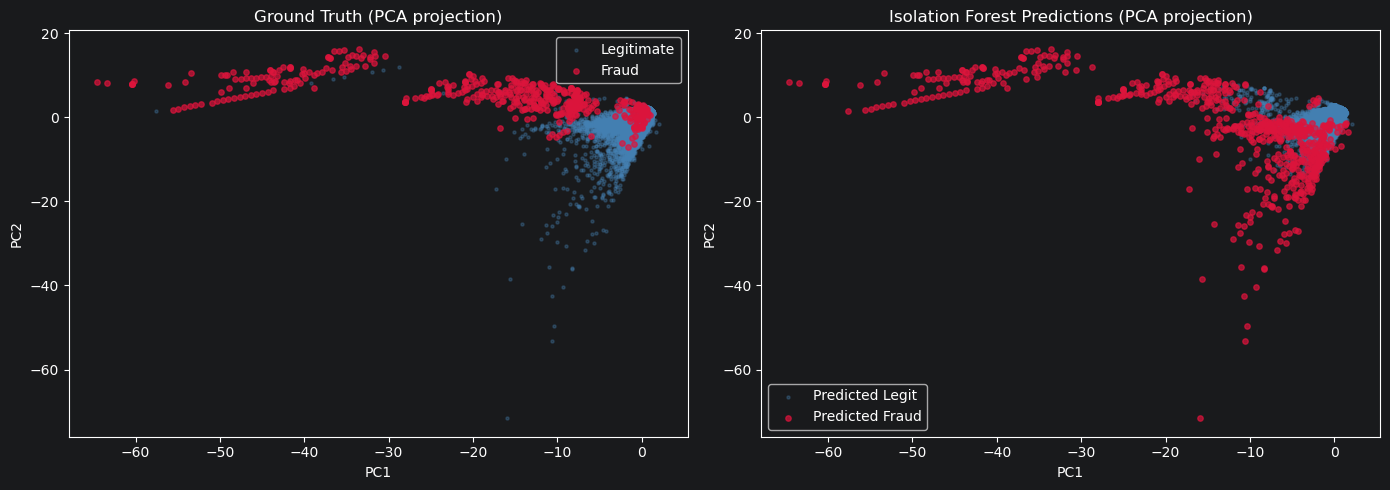

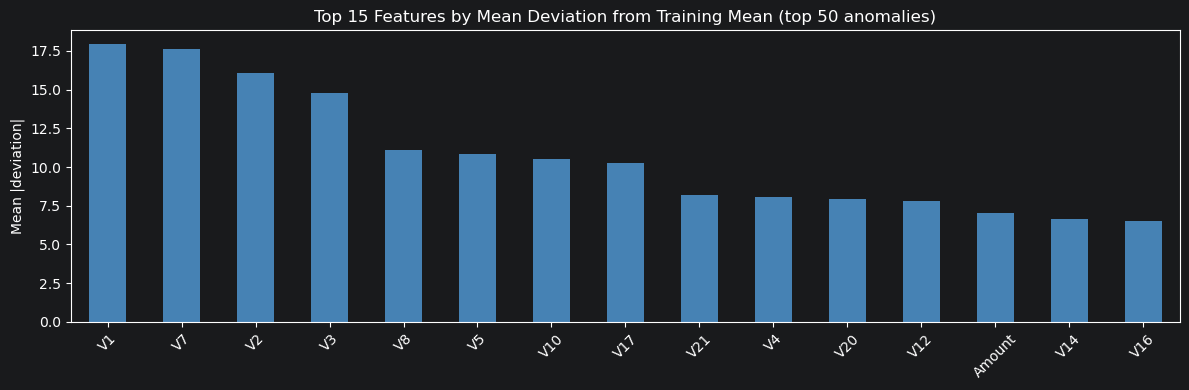

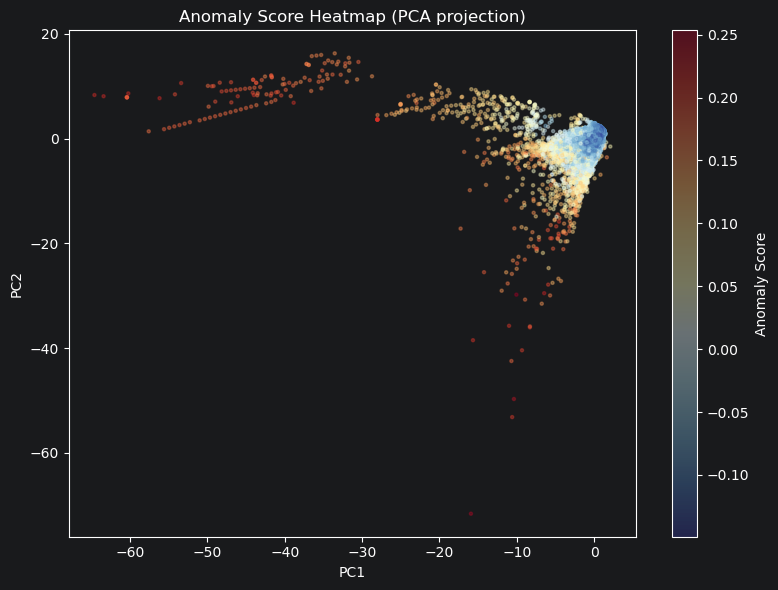

Top features driving anomalies:
V1     17.931964
V7     17.614079
V2     16.078066
V3     14.767840
V8     11.117715
V5     10.817727
V10    10.491250
V17    10.281963
V21     8.220439
V4      8.044974


In [22]:
# PCA visualization of anomalies
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

fig6, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ground truth
axes[0].scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1],
                alpha=0.3, s=5, label='Legitimate', color='steelblue')
axes[0].scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1],
                alpha=0.7, s=15, label='Fraud', color='crimson')
axes[0].set_title('Ground Truth (PCA projection)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# Predictions
axes[1].scatter(X_test_pca[y_pred == 0, 0], X_test_pca[y_pred == 0, 1],
                alpha=0.3, s=5, label='Predicted Legit', color='steelblue')
axes[1].scatter(X_test_pca[y_pred == 1, 0], X_test_pca[y_pred == 1, 1],
                alpha=0.7, s=15, label='Predicted Fraud', color='crimson')
axes[1].set_title('Isolation Forest Predictions (PCA projection)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
mlflow.log_figure(fig6, "pca_visualization.png")
plt.show()

# Feature deviation for top anomalies
top_idx = np.argsort(scores)[-50:]
train_mean = X_train.mean(axis=0)
top_df = pd.DataFrame(X_test[top_idx], columns=feature_names)
deviation = (top_df - train_mean).abs().mean().sort_values(ascending=False)

fig7, ax = plt.subplots(figsize=(12, 4))
deviation.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 Features by Mean Deviation from Training Mean (top 50 anomalies)')
ax.set_ylabel('Mean |deviation|')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
mlflow.log_figure(fig7, "feature_deviation.png")
plt.show()

# Anomaly score coloured scatter
fig8, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                c=scores, cmap='RdYlBu_r', alpha=0.4, s=5, vmin=scores.min(), vmax=scores.max())
plt.colorbar(sc, ax=ax, label='Anomaly Score')
ax.set_title('Anomaly Score Heatmap (PCA projection)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
mlflow.log_figure(fig8, "anomaly_heatmap.png")
plt.show()

print(f"Top features driving anomalies:\n{deviation.head(10).to_string()}")

---

In [23]:
mlflow.end_run()
print("Run complete.")

Run complete.
